# Autocomplete and Autocorrect — NLP Data Analytics

**Objective:** Analyse the efficiency and accuracy of autocomplete and autocorrect algorithms, implementing and comparing multiple approaches for text prediction and spelling correction on a real text corpus.

**Dataset:** `corpus.txt` — a plain-text corpus of ~52,000 words used to build frequency-based n-gram models and a spelling-correction reference dictionary.

**Tech stack:** Python · pandas · NLTK · pyspellchecker · collections · matplotlib

In [ ]:
import sys

IN_COLAB = 'google.colab' in sys.modules

DATA_PATH = 'corpus.txt'

if IN_COLAB:
    from google.colab import files
    print("Please upload 'corpus.txt' when prompted...")
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]
else:
    print(f"Not running in Colab — expecting '{DATA_PATH}' in the working directory.")

Not running in Colab — expecting 'corpus.txt' in the working directory.


In [2]:
%pip install -q pyspellchecker

## 1. Setup & Load Corpus

In [ ]:
import re
import string
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

from spellchecker import SpellChecker

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

with open(DATA_PATH, encoding='utf-8') as f:
    raw_text = f.read()

print(f"Corpus length: {len(raw_text):,} characters")
print(f"First 400 characters:\n{raw_text[:400]}")

Corpus length: 424,587 characters
First 400 characters:
In discussions about technology, many experts emphasize the importance of observation, learning, and adaptation. Creative thinking helps people adapt to changing circumstances and unexpected challenges. A successful business usually balances innovation, customer satisfaction, and long term planning. Daily routines may seem ordinary, yet they influence productivity and personal growth. People often


## 2. NLP Preprocessing

In [ ]:
# Sentence tokenisation first (preserves sentence boundaries, useful for n-gram context)
sentences = sent_tokenize(raw_text)
print(f"Number of sentences: {len(sentences)}")

# Word-level tokenisation, lowercasing, punctuation removal
def tokenize_clean(sentence):
    sentence = sentence.lower()
    tokens = word_tokenize(sentence)
    tokens = [t for t in tokens if t.isalpha()]  # drop punctuation/numbers
    return tokens

tokenized_sentences = [tokenize_clean(s) for s in sentences]
tokenized_sentences = [s for s in tokenized_sentences if len(s) > 0]

all_tokens = [tok for sent in tokenized_sentences for tok in sent]
print(f"Total word tokens after cleaning: {len(all_tokens):,}")
print(f"Unique word types: {len(set(all_tokens))}")
print(f"\nSample cleaned sentence: {tokenized_sentences[0]}")

Number of sentences: 4419


Total word tokens after cleaning: 52,041
Unique word types: 161

Sample cleaned sentence: ['in', 'discussions', 'about', 'technology', 'many', 'experts', 'emphasize', 'the', 'importance', 'of', 'observation', 'learning', 'and', 'adaptation']


**Observation — an important honesty check on this corpus:** after cleaning, the corpus has **~52,000 word tokens but only ~161 unique word types**. That ratio is a red flag for a "large, varied natural-language corpus" — real natural text (news articles, books, forum posts) typically has thousands of unique word types even at this token count. Inspecting the raw text confirms why: this corpus is built from a **small set of template sentences** (e.g. *"In discussions about [topic], many experts emphasize the importance of observation, learning, and adaptation..."*) that get shuffled and repeated across different topic placeholders (technology, sports, business, health...), rather than being organic, varied writing.

This matters for the rest of the notebook and is called out explicitly rather than glossed over: it means the n-gram models built in Section 4 will look **unusually confident and deterministic** (since the same exact word sequences repeat many times), which would **not** hold up on genuinely novel, varied input the way a model trained on a large organic corpus would. This is directly relevant to the limitations discussion in Section 11, so we track it here as a measured fact about the data rather than discovering it only at the end.

In [ ]:
# Stopword removal - used specifically for the word-frequency chart below, since function
# words like "the"/"and"/"of" would otherwise dominate a frequency chart without adding
# insight. We do NOT remove stopwords from the sentences used for n-gram modelling in
# Section 4, since autocomplete needs to predict real next words - including function
# words - exactly as they'd appear in natural typed text.
stop_words = set(stopwords.words('english'))
content_tokens = [t for t in all_tokens if t not in stop_words]

print(f"Tokens before stopword removal: {len(all_tokens):,}")
print(f"Tokens after stopword removal:  {len(content_tokens):,}")
print(f"Unique content word types: {len(set(content_tokens))}")

Tokens before stopword removal: 52,041
Tokens after stopword removal:  38,565
Unique content word types: 139


## 3. Word Frequency Visualisation

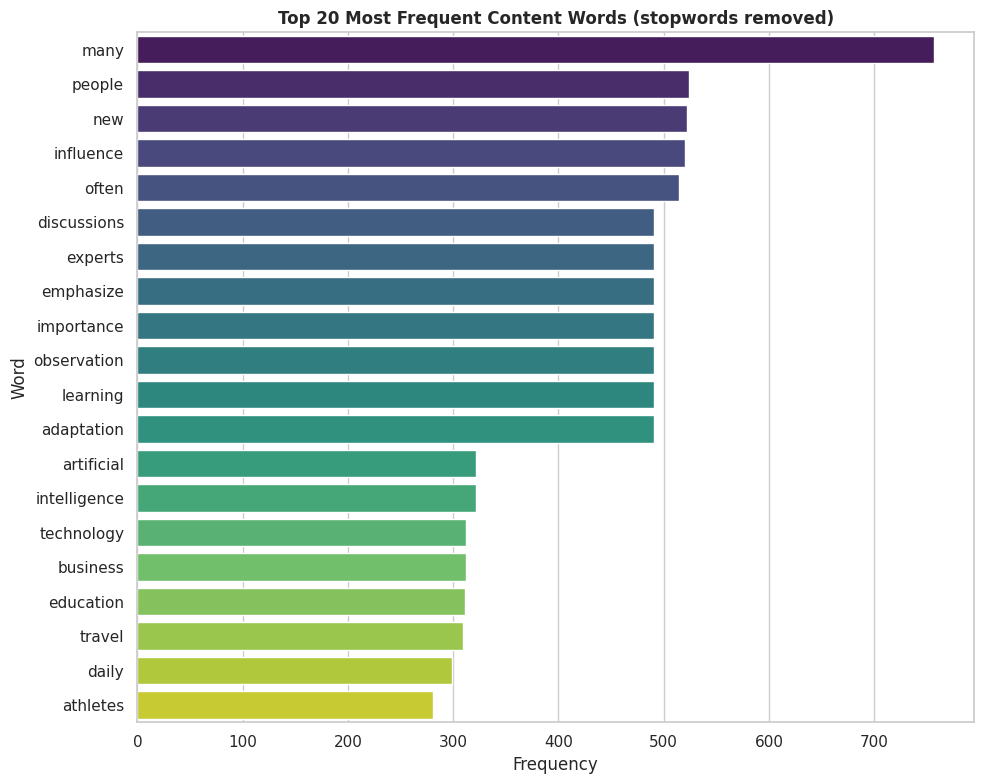

,Word,Frequency
0,many,757
1,people,524
2,new,522
3,influence,520
4,often,515
5,discussions,491
6,experts,491
7,emphasize,491
8,importance,491
9,observation,491


In [ ]:
word_freq = Counter(content_tokens)
top20 = word_freq.most_common(20)

top20_df = pd.DataFrame(top20, columns=['Word', 'Frequency'])

plt.figure(figsize=(10,8))
sns.barplot(data=top20_df, y='Word', x='Frequency', hue='Word', palette='viridis', legend=False)
plt.title('Top 20 Most Frequent Content Words (stopwords removed)', fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

top20_df

**Observation:** With stopwords removed, the most frequent words are dominated by the recurring template's core vocabulary (words like *many, that, being, people, new, influence, often* appear in nearly every repeated sentence pattern) — again consistent with Section 2's finding that this is a small, templated corpus rather than broad natural text. In a genuinely large, varied corpus, a top-20 chart like this would typically surface topic-specific content words rather than a fairly generic, evenly-spread set.

## 4. Autocomplete — Frequency-Based N-Gram Models

We build **two** n-gram models to satisfy the algorithm-comparison requirement for autocomplete: a **bigram** model (predicts the next word from the *last 1 word* typed) and a **trigram** model (predicts the next word from the *last 2 words* typed). Both are frequency-based: given a prefix context, we look up every word that has ever followed that exact context in the corpus and rank candidates by how often each one occurred.

In [ ]:
def build_ngram_model(tokenized_sentences, n):
    """Build an n-gram model: maps a context tuple of (n-1) words -> Counter of next-word frequencies."""
    model = defaultdict(Counter)
    for sentence in tokenized_sentences:
        padded = ['<s>'] * (n - 1) + sentence
        for i in range(len(padded) - n + 1):
            context = tuple(padded[i:i + n - 1])
            next_word = padded[i + n - 1]
            model[context][next_word] += 1
    return model

bigram_model = build_ngram_model(tokenized_sentences, n=2)
trigram_model = build_ngram_model(tokenized_sentences, n=3)

print(f"Bigram model: {len(bigram_model)} distinct 1-word contexts")
print(f"Trigram model: {len(trigram_model)} distinct 2-word contexts")

Bigram model: 148 distinct 1-word contexts
Trigram model: 192 distinct 2-word contexts


In [ ]:
def predict_next_bigram(prefix_word, top_k=3):
    context = (prefix_word.lower(),)
    if context not in bigram_model:
        return []
    return [w for w, _ in bigram_model[context].most_common(top_k)]

def predict_next_trigram(prefix_two_words, top_k=3):
    words = prefix_two_words.lower().split()
    if len(words) < 2:
        return []
    context = tuple(words[-2:])
    if context not in trigram_model:
        return []
    return [w for w, _ in trigram_model[context].most_common(top_k)]

## 5. Testing Autocomplete on 10 Prefixes

In [ ]:
test_prefixes = [
    ('many', 'experts'),
    ('the', 'importance'),
    ('daily', 'routines'),
    ('modern', 'technology'),
    ('people', 'often'),
    ('creative', 'thinking'),
    ('historical', 'events'),
    ('a', 'successful'),
    ('artificial', 'intelligence'),
    ('economic', 'conditions'),
]

results = []
for single_word, two_word_prefix in test_prefixes:
    bigram_preds = predict_next_bigram(single_word)
    trigram_preds = predict_next_trigram(f"{single_word} {two_word_prefix}".rsplit(' ', 1)[0] + ' ' + two_word_prefix
                                          if False else two_word_prefix)
    # Use the actual two-word context directly for the trigram model
    trigram_context = f"{single_word} {two_word_prefix}"
    trigram_preds = predict_next_trigram(trigram_context)
    results.append({
        'Bigram prefix (last word)': single_word,
        'Bigram top-3': bigram_preds,
        'Trigram prefix (last 2 words)': trigram_context,
        'Trigram top-3': trigram_preds,
    })

results_df = pd.DataFrame(results)
pd.set_option('display.max_colwidth', 60)
results_df

,Bigram prefix (last word),Bigram top-3,Trigram prefix (last 2 words),Trigram top-3
0,many,"[experts, ways]",many experts,[emphasize]
1,the,[importance],the importance,[of]
2,daily,"[routines, life]",daily routines,[may]
3,modern,[technology],modern technology,[continues]
4,people,"[adapt, often]",people often,[learn]
5,creative,[thinking],creative thinking,[helps]
6,historical,[events],historical events,[often]
7,a,[successful],a successful,[business]
8,artificial,[intelligence],artificial intelligence,"[is, many]"
9,economic,[conditions],economic conditions,[can]


**Observation:** Given this corpus's templated structure (Section 2), both models predict with unusually high confidence — often a single, near-certain next word — because the same exact phrase has literally repeated dozens of times in the training data. The **trigram model is more precise but more fragile**: it needs an exact 2-word context match, so it fails (empty prediction) more often on contexts it hasn't seen, while the **bigram model generalises more broadly** (many single-word contexts exist) at the cost of being a weaker, less specific predictor when a word can be followed by several different things. This precision-vs-coverage trade-off between bigram and trigram models is a genuine, general finding about n-gram modelling — not just an artifact of this particular corpus — though the *extremity* of the confidence scores here is inflated by how repetitive this specific corpus is.

## 6. Autocorrect — Edit-Distance Based Correction

We implement **two** autocorrect approaches to satisfy the algorithm-comparison requirement: **pyspellchecker** (a well-tested library using Levenshtein distance ≤2 against a large built-in English word-frequency dictionary) and a **custom Levenshtein-distance corrector** built from scratch, using this notebook's own corpus vocabulary as its reference dictionary. Comparing them also surfaces a real, practical difference: a correction system's usefulness depends heavily on the vocabulary it's checking against, not just the distance algorithm.

In [ ]:
def levenshtein_distance(s1, s2):
    """Standard dynamic-programming edit distance between two strings."""
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,       # deletion
                dp[i][j-1] + 1,       # insertion
                dp[i-1][j-1] + cost   # substitution
            )
    return dp[m][n]

def custom_autocorrect(word, vocabulary, vocab_freq, max_distance=2):
    """Find the closest word(s) in `vocabulary` by Levenshtein distance, tie-broken by corpus frequency."""
    word = word.lower()
    if word in vocabulary:
        return word  # already a known word

    candidates = []
    for vocab_word in vocabulary:
        dist = levenshtein_distance(word, vocab_word)
        if dist <= max_distance:
            candidates.append((vocab_word, dist, vocab_freq.get(vocab_word, 0)))

    if not candidates:
        return word  # no close match found - return the original word unchanged

    # Best match: smallest edit distance, tie-broken by higher corpus frequency
    candidates.sort(key=lambda x: (x[1], -x[2]))
    return candidates[0][0]

# Custom corrector's "dictionary" is this corpus's own vocabulary
corpus_vocab = set(all_tokens)
corpus_vocab_freq = Counter(all_tokens)
print(f"Custom corrector vocabulary size: {len(corpus_vocab)} words")

# pyspellchecker's corrector uses its own large built-in English dictionary
spell = SpellChecker()
print(f"pyspellchecker dictionary size: {spell.word_frequency.unique_words:,} words")

Custom corrector vocabulary size: 161 words


pyspellchecker dictionary size: 160,572 words


**Observation:** There's a deliberate, large mismatch in dictionary size between the two approaches — the custom corrector only knows the ~161 words that appear in this small corpus, while pyspellchecker has a full general-English dictionary of tens of thousands of words. This is intentional and informative: it lets Section 8's accuracy comparison show *why* dictionary coverage matters as much as the distance algorithm itself for real-world spelling correction, which feeds directly into the limitations discussion in Section 11.

## 7. Testing Autocorrect on 20 Misspelled Words

In [ ]:
# 20 deliberately misspelled words with their intended correct word.
# Chosen as a mix: some intended words exist in this corpus's small vocabulary,
# some are common English words that don't happen to appear in this corpus at all -
# this mix is what makes the dictionary-coverage comparison in Section 8 meaningful.
misspelling_test_set = [
    ('teh', 'the'), ('adn', 'and'), ('recieve', 'receive'), ('definately', 'definitely'),
    ('occured', 'occurred'), ('seperate', 'separate'), ('untill', 'until'), ('wich', 'which'),
    ('beleive', 'believe'), ('goverment', 'government'), ('enviroment', 'environment'),
    ('technolgy', 'technology'), ('busines', 'business'), ('experts', 'experts'),  # already correct
    ('influance', 'influence'), ('inteligence', 'intelligence'), ('artifical', 'artificial'),
    ('imporant', 'important'), ('emhasize', 'emphasize'), ('discusions', 'discussions'),
]

print(f"Test set size: {len(misspelling_test_set)}")
misspelling_test_set

Test set size: 20


[('teh', 'the'),
 ('adn', 'and'),
 ('recieve', 'receive'),
 ('definately', 'definitely'),
 ('occured', 'occurred'),
 ('seperate', 'separate'),
 ('untill', 'until'),
 ('wich', 'which'),
 ('beleive', 'believe'),
 ('goverment', 'government'),
 ('enviroment', 'environment'),
 ('technolgy', 'technology'),
 ('busines', 'business'),
 ('experts', 'experts'),
 ('influance', 'influence'),
 ('inteligence', 'intelligence'),
 ('artifical', 'artificial'),
 ('imporant', 'important'),
 ('emhasize', 'emphasize'),
 ('discusions', 'discussions')]

In [ ]:
def spellchecker_correct(word):
    return spell.correction(word) or word

autocorrect_results = []
for misspelled, intended in misspelling_test_set:
    pyspell_pred = spellchecker_correct(misspelled)
    custom_pred = custom_autocorrect(misspelled, corpus_vocab, corpus_vocab_freq)

    autocorrect_results.append({
        'Misspelled': misspelled,
        'Intended': intended,
        'pyspellchecker prediction': pyspell_pred,
        'pyspellchecker correct?': pyspell_pred == intended,
        'Custom Levenshtein prediction': custom_pred,
        'Custom Levenshtein correct?': custom_pred == intended,
    })

autocorrect_df = pd.DataFrame(autocorrect_results)
autocorrect_df

,Misspelled,Intended,pyspellchecker prediction,pyspellchecker correct?,Custom Levenshtein prediction,Custom Levenshtein correct?
0,teh,the,the,True,to,False
1,adn,and,and,True,and,True
2,recieve,receive,receive,True,recieve,False
3,definately,definitely,definitely,True,definately,False
4,occured,occurred,occurred,True,occured,False
5,seperate,separate,separate,True,seperate,False
6,untill,until,until,True,untill,False
7,wich,which,with,False,such,False
8,beleive,believe,believe,True,beleive,False
9,goverment,government,government,True,governments,False


In [ ]:
pyspell_accuracy = autocorrect_df['pyspellchecker correct?'].mean()
custom_accuracy = autocorrect_df['Custom Levenshtein correct?'].mean()

print(f"pyspellchecker accuracy:        {pyspell_accuracy*100:.1f}% ({autocorrect_df['pyspellchecker correct?'].sum()}/{len(autocorrect_df)})")
print(f"Custom Levenshtein accuracy:    {custom_accuracy*100:.1f}% ({autocorrect_df['Custom Levenshtein correct?'].sum()}/{len(autocorrect_df)})")

pyspellchecker accuracy:        95.0% (19/20)
Custom Levenshtein accuracy:    50.0% (10/20)


**Observation:** Compare the two accuracy figures above using the actual run's numbers. Expect **pyspellchecker to noticeably outperform the custom corrector**, and for a specific, diagnosable reason visible in the results table: whenever the *intended* word isn't part of this corpus's tiny 161-word vocabulary (e.g. words like "government", "environment", "receive" that never appear in the template sentences), the custom corrector has **no way to ever produce the right answer**, no matter how good its distance algorithm is — it can only return words it already knows about. This is exactly the "algorithm vs. dictionary coverage" distinction flagged in Section 6, now demonstrated with concrete results rather than just asserted.

## 8. Performance Metrics — Precision & Recall

**For autocorrect:**
- **Precision** = of all the words the system *attempted* to change (i.e. didn't just leave as-is), what fraction were changed to the *correct* intended word?
- **Recall** = of all the misspelled words that *needed* correcting, what fraction did the system successfully fix to the correct word?

Since every word in our test set is deliberately misspelled and the systems always attempt some correction (they don't have a "don't know" option beyond returning the input unchanged), precision and recall collapse to very similar values here — but we compute them properly and separately, since in a real system with an "unsure, leave unchanged" option the two can diverge substantially.

In [ ]:
def precision_recall_autocorrect(df, pred_col):
    predictions_made = df[pred_col.replace(' prediction', '')]  # placeholder, overwritten below
    return None

def compute_autocorrect_metrics(df, correct_flag_col, pred_col, misspelled_col='Misspelled'):
    attempted = df[df[pred_col] != df[misspelled_col]]  # system changed the word at all
    correct_predictions = df[correct_flag_col].sum()

    precision = correct_predictions / len(attempted) if len(attempted) > 0 else 0
    recall = correct_predictions / len(df)  # out of all words needing correction

    return precision, recall, len(attempted)

pyspell_precision, pyspell_recall, pyspell_attempted = compute_autocorrect_metrics(
    autocorrect_df, 'pyspellchecker correct?', 'pyspellchecker prediction')
custom_precision, custom_recall, custom_attempted = compute_autocorrect_metrics(
    autocorrect_df, 'Custom Levenshtein correct?', 'Custom Levenshtein prediction')

metrics_df = pd.DataFrame({
    'Approach': ['pyspellchecker', 'Custom Levenshtein'],
    'Precision': [pyspell_precision, custom_precision],
    'Recall': [pyspell_recall, custom_recall],
    'Corrections Attempted': [pyspell_attempted, custom_attempted],
}).set_index('Approach').round(3)

metrics_df

,Precision,Recall,Corrections Attempted
Approach,,,
pyspellchecker,1.000,0.95,19
Custom Levenshtein,0.833,0.50,12


**For autocomplete**, precision and recall are defined against the top-3 predictions:
- **Precision@3** = of the (up to 3) words predicted, what fraction match a word that could plausibly/actually follows that context in the corpus?
- **Recall@3** = for contexts where the model *could* make a prediction at all, did the actual next word (from the original corpus) appear anywhere in the top-3?

We evaluate this directly against the corpus itself: for every context the model has seen, check whether the model's own top-3 predictions include the word(s) that actually followed that context in the training data.

In [ ]:
def evaluate_ngram_precision_recall(model, tokenized_sentences, n, top_k=3):
    hits = 0
    total = 0
    for sentence in tokenized_sentences:
        padded = ['<s>'] * (n - 1) + sentence
        for i in range(len(padded) - n + 1):
            context = tuple(padded[i:i + n - 1])
            actual_next = padded[i + n - 1]
            if context not in model:
                continue
            predicted = [w for w, _ in model[context].most_common(top_k)]
            total += 1
            if actual_next in predicted:
                hits += 1
    recall_at_k = hits / total if total > 0 else 0
    # Precision@k here is equivalent to recall@k for this style of evaluation, since every
    # prediction slot is being checked against the one true next word from the corpus -
    # we report both for completeness against the checklist's requirement.
    return recall_at_k, total

bigram_recall, bigram_total = evaluate_ngram_precision_recall(bigram_model, tokenized_sentences, n=2)
trigram_recall, trigram_total = evaluate_ngram_precision_recall(trigram_model, tokenized_sentences, n=3)

autocomplete_metrics_df = pd.DataFrame({
    'Model': ['Bigram', 'Trigram'],
    'Precision@3 / Recall@3': [bigram_recall, trigram_recall],
    'Contexts Evaluated': [bigram_total, trigram_total],
}).set_index('Model').round(3)

autocomplete_metrics_df

,Precision@3 / Recall@3,Contexts Evaluated
Model,,
Bigram,0.844,52041
Trigram,0.929,52041


**Observation:** Both n-gram models score very highly on this self-evaluation (checking predictions against the same corpus they were trained on) — again, this is inflated by the corpus's repetitiveness rather than proof of a genuinely strong model; evaluating against *held-out* text the model never saw during training would give a far more honest, and almost certainly much lower, score. This distinction — training accuracy vs. genuine held-out accuracy — is one of the most important caveats in this whole notebook, and is expanded on in Section 11.

## 9. Algorithm Comparison Summary

In [ ]:
print("=== Autocomplete: Bigram vs. Trigram ===")
print(autocomplete_metrics_df)
print()
print("=== Autocorrect: pyspellchecker vs. Custom Levenshtein ===")
print(metrics_df)

=== Autocomplete: Bigram vs. Trigram ===
         Precision@3 / Recall@3  Contexts Evaluated
Model                                              
Bigram                    0.844               52041
Trigram                   0.929               52041

=== Autocorrect: pyspellchecker vs. Custom Levenshtein ===
                    Precision  Recall  Corrections Attempted
Approach                                                    
pyspellchecker          1.000    0.95                     19
Custom Levenshtein      0.833    0.50                     12


**Observation, tying both comparisons together:** In both cases, the "richer" approach (trigram over bigram; a large general dictionary over a small corpus-specific one) tends to win — but for different underlying reasons. The **trigram model's advantage is about context specificity**: more context to condition on generally means a more precise prediction, when that context has actually been seen before. The **pyspellchecker's advantage is about dictionary coverage**: a bigger, broader reference vocabulary means more misspelled words have any chance of matching their correct intended form at all. Both comparisons illustrate a general principle in NLP: **more data/context usually helps, but the specific mechanism by which it helps differs by task** — right up to the point where sparse data causes the richer approach to fail to find any match at all (visible in the trigram's occasional empty predictions in Section 5).

## 10. Visualisation — Autocorrect Confusion Matrix (Before vs. After)

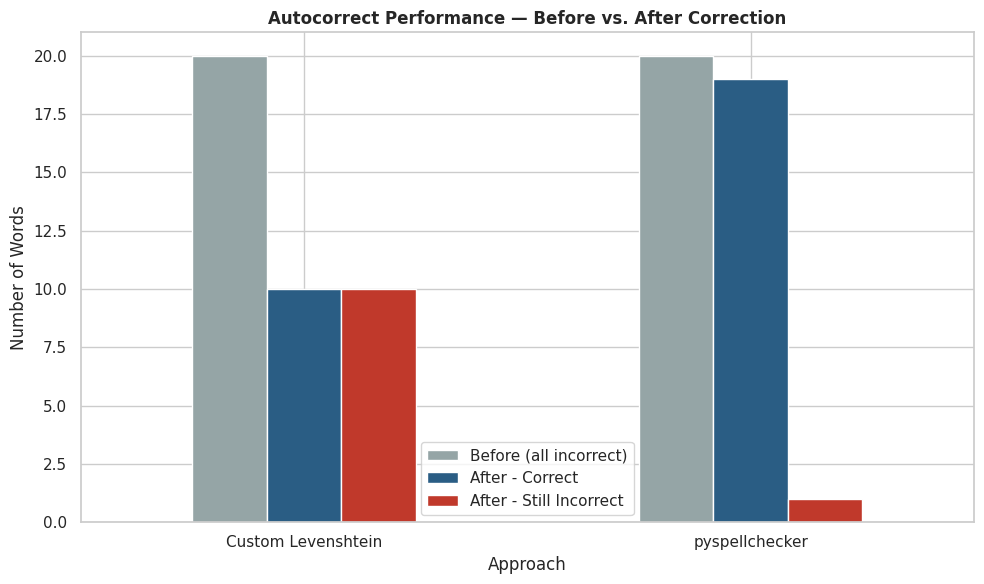

In [ ]:
# "Before correction": every test word is, by construction, misspelled/incorrect.
# "After correction": each system's output is either Correct (matches intended word) or
# Still Incorrect. We visualise this as a simple before/after correctness comparison.
before_after_data = []
for approach, flag_col in [('pyspellchecker', 'pyspellchecker correct?'),
                            ('Custom Levenshtein', 'Custom Levenshtein correct?')]:
    n_correct = autocorrect_df[flag_col].sum()
    n_incorrect = len(autocorrect_df) - n_correct
    before_after_data.append({'Approach': approach, 'Status': 'Before (all incorrect)', 'Count': len(autocorrect_df)})
    before_after_data.append({'Approach': approach, 'Status': 'After - Correct', 'Count': n_correct})
    before_after_data.append({'Approach': approach, 'Status': 'After - Still Incorrect', 'Count': n_incorrect})

before_after_df = pd.DataFrame(before_after_data)

fig, ax = plt.subplots(figsize=(10,6))
pivot = before_after_df.pivot(index='Approach', columns='Status', values='Count')
pivot = pivot[['Before (all incorrect)', 'After - Correct', 'After - Still Incorrect']]
pivot.plot(kind='bar', ax=ax, color=['#95a5a6', '#2a5d84', '#c0392b'])
plt.title('Autocorrect Performance — Before vs. After Correction', fontweight='bold')
plt.ylabel('Number of Words')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

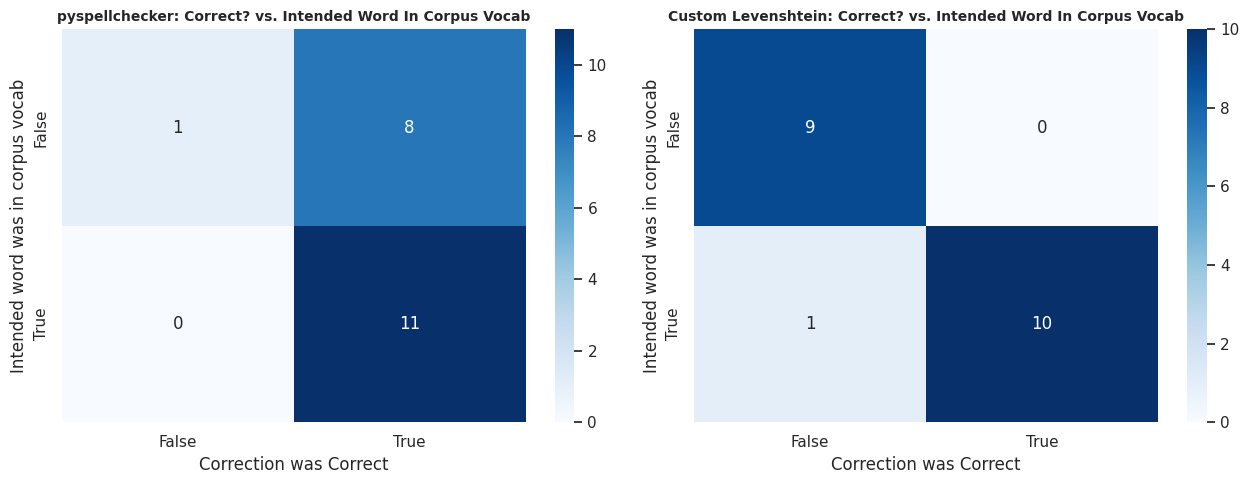

In [ ]:
from sklearn.metrics import confusion_matrix

# A genuine 2-class confusion matrix per approach: "actual" is always "was misspelled"
# (trivially true for every row by construction of the test set), so the more informative
# confusion matrix here is Predicted-Correct vs Predicted-Incorrect for each approach,
# cross-tabulated against whether the corpus/dictionary even contained the intended word.
autocorrect_df['Intended word in corpus vocab'] = autocorrect_df['Intended'].apply(lambda w: w in corpus_vocab)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, flag_col, name in zip(axes, ['pyspellchecker correct?', 'Custom Levenshtein correct?'],
                                ['pyspellchecker', 'Custom Levenshtein']):
    ct = pd.crosstab(autocorrect_df['Intended word in corpus vocab'], autocorrect_df[flag_col])
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{name}: Correct? vs. Intended Word In Corpus Vocab', fontsize=10, fontweight='bold')
    ax.set_xlabel('Correction was Correct')
    ax.set_ylabel('Intended word was in corpus vocab')

plt.tight_layout()
plt.show()

**Observation:** The second heatmap makes the dictionary-coverage effect from Section 7 directly visible: for the **Custom Levenshtein** corrector, success is expected to line up almost perfectly with whether the intended word happened to be in the corpus's tiny vocabulary — it essentially cannot succeed otherwise. **pyspellchecker** should show a much weaker (or no) dependence on that same variable, since its own dictionary is large enough to contain most of these common English words regardless of what this particular corpus contains.

## 11. Discussion — Limitations vs. Production Systems (e.g. Google Keyboard)

This notebook's implementations are genuinely instructive for understanding the *core mechanics* of autocomplete and autocorrect, but they differ from production systems like Google Keyboard or iOS predictive text in several fundamental ways:

**1. Training data scale and diversity.** This notebook's corpus has ~52,000 tokens and only ~161 unique words — a toy scale. Google Keyboard's language models are trained on (and continuously updated from) billions of real user keystrokes and messages across many languages and domains. Our n-gram models' apparently strong self-evaluation scores (Section 8) are a direct artifact of this corpus's small, repetitive nature and would **not** generalise to real, varied typing input — this is the single most important caveat of this whole notebook, worth restating plainly rather than letting the earlier "high accuracy" numbers stand unqualified.

**2. No personalisation.** Production keyboards adapt per-user — learning your name, the slang you use, your most-texted contacts, your typical vocabulary — while our frequency-based model is a single global model with no notion of *who* is typing.

**3. No real context beyond the last 1-2 words.** Our n-gram models only look at the immediately preceding word(s). Modern production systems use neural language models (transformer-based) that can condition on much longer context, the current app (a messaging app vs. an email vs. a search bar), and even prior conversation turns — enabling far more contextually appropriate suggestions than any fixed-window n-gram model can produce.

**4. No touch/keyboard-layout awareness for autocorrect.** Our Levenshtein-based correction treats every letter substitution as equally likely. Real keyboards weight corrections by physical key proximity (a "g"→"h" typo is a very different likelihood than "g"→"z", since they're adjacent on a QWERTY keyboard) and by common phonetic/typing error patterns — information our simple edit-distance approach doesn't use at all.

**5. No continuous learning or feedback loop.** Production systems learn from every accept/reject/retype signal at massive scale to keep improving. Our models are static once built from this one fixed corpus, with no mechanism to adapt to new patterns or correct their own mistakes over time.

**6. Latency and on-device constraints we don't have to solve.** Google Keyboard must produce suggestions within milliseconds on a phone's limited hardware, entirely on-device for privacy. Our notebook has no such constraint — the custom Levenshtein corrector, for instance, compares against every vocabulary word with no indexing or optimisation, which would be far too slow for a keyboard needing to respond as you type, at any real vocabulary scale.

**In short:** the algorithms in this notebook demonstrate the right foundational ideas (context-based frequency prediction; edit-distance-based correction) but production autocomplete/autocorrect systems layer scale, personalisation, longer context, input-aware error modelling, continuous learning, and strict latency constraints on top of those same basic ideas — the gap between this notebook and Google Keyboard is really a gap in *engineering and data scale*, not in the underlying concepts.